# 02. 최종 취약지수 검증·시각화

01 실행 후 실행한다. 기존 점수는 바꾸지 않으며 그래프는 노트북 출력에만 저장한다.
전체 대상 격자 분포와 상위 10%는 EDA용이다. 접근성 후보 기준 미정 시 실제 우선지원 후보로 해석하지 않는다.
물리적·비물리적 점수 모두 0~1이지만 분산이 달라 명목상 50:50이 같은 순위 영향력을 보장하지 않는다.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display
start=Path.cwd().resolve()
ROOT=next(p for p in [start,*start.parents] if (p/'data/raw').is_dir() and (p/'code').is_dir())
OUT=ROOT/'data/processed/final_score/서울시_100m_최종취약지수'
pd.set_option('display.max_columns',30)

In [2]:
import matplotlib.pyplot as plt
from matplotlib import font_manager
for font in ['Malgun Gothic','Noto Sans CJK KR','AppleGothic']:
    if font in {f.name for f in font_manager.fontManager.ttflist}:
        plt.rcParams['font.family']=font;break
plt.rcParams.update({'axes.unicode_minus':False,'figure.dpi':110})
df=pd.read_csv(OUT/'서울시_100m_최종취약지수.csv')
cols=['물리적부족도','비물리적지수','최종취약지수']
assert not df['GRID_CD'].duplicated().any()
assert df[cols].notna().all().all() and df[cols].ge(0).all().all() and df[cols].le(1).all().all()
assert np.allclose(df['최종취약지수'],.5*df['물리적부족도']+.5*df['비물리적지수'])
display(df[cols].describe().round(4))

,물리적부족도,비물리적지수,최종취약지수
count,21263.0000,21263.0000,21263.0000
mean,0.5053,0.5072,0.5062
std,0.2024,0.1800,0.1369
min,0.0000,0.0706,0.1368
25%,0.3512,0.3569,0.4033
50%,0.4623,0.5078,0.5029
75%,0.6387,0.6559,0.6011
max,1.0000,0.8931,0.9411


## 1. 점수 분포와 순위상관

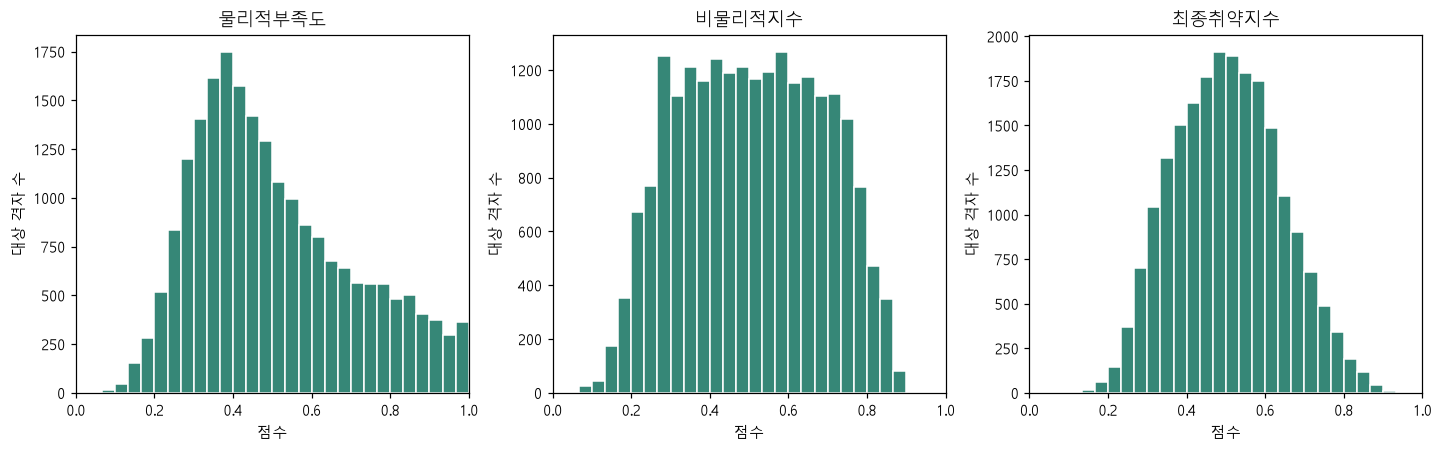

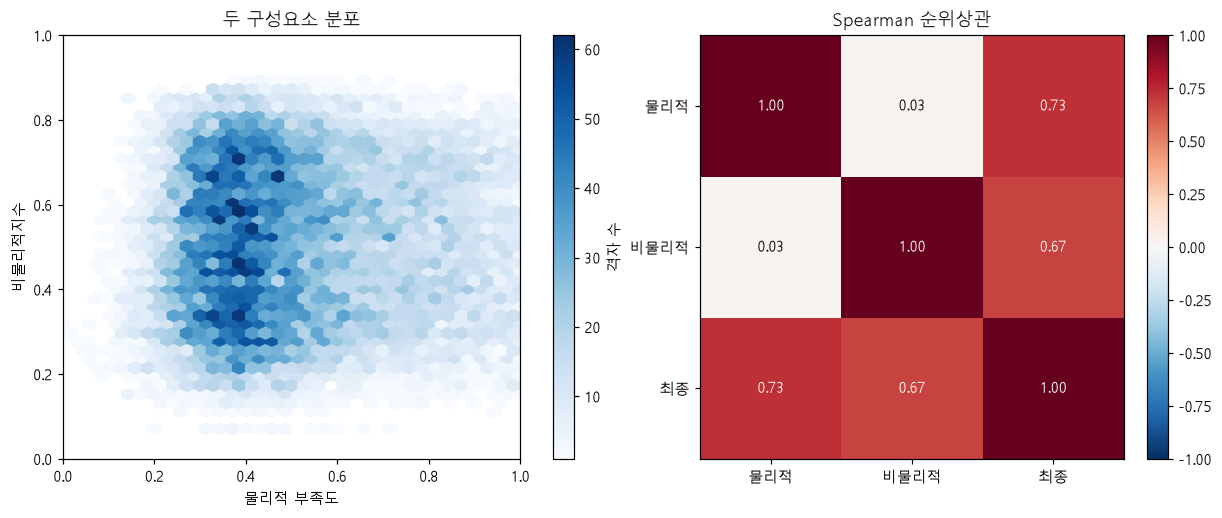

In [3]:
fig,axes=plt.subplots(1,3,figsize=(13,4),layout='constrained')
for ax,col in zip(axes,cols):
    ax.hist(df[col],bins=np.linspace(0,1,31),color='#368777',edgecolor='white')
    ax.set(xlim=(0,1),xlabel='점수',ylabel='대상 격자 수',title=col)
plt.show()
corr=df[cols].rank().corr()
fig,axes=plt.subplots(1,2,figsize=(11,4.6),layout='constrained')
h=axes[0].hexbin(df['물리적부족도'],df['비물리적지수'],gridsize=35,mincnt=1,cmap='Blues')
axes[0].set(xlabel='물리적 부족도',ylabel='비물리적지수',xlim=(0,1),ylim=(0,1),title='두 구성요소 분포')
fig.colorbar(h,ax=axes[0],label='격자 수')
im=axes[1].imshow(corr,vmin=-1,vmax=1,cmap='RdBu_r')
axes[1].set_xticks(range(3),['물리적','비물리적','최종']);axes[1].set_yticks(range(3),['물리적','비물리적','최종'])
for y in range(3):
    for x in range(3):axes[1].text(x,y,f'{corr.iloc[y,x]:.2f}',ha='center',va='center',color='white' if abs(corr.iloc[y,x])>.6 else 'black')
axes[1].set_title('Spearman 순위상관');fig.colorbar(im,ax=axes[1]);plt.show()

## 2. 격자 중심점 공간분포
원본 GPKG 투영좌표를 km로 표시한 산점도이며 위경도가 아니다. 세 그림의 색상 범위는 0~1로 동일하다.

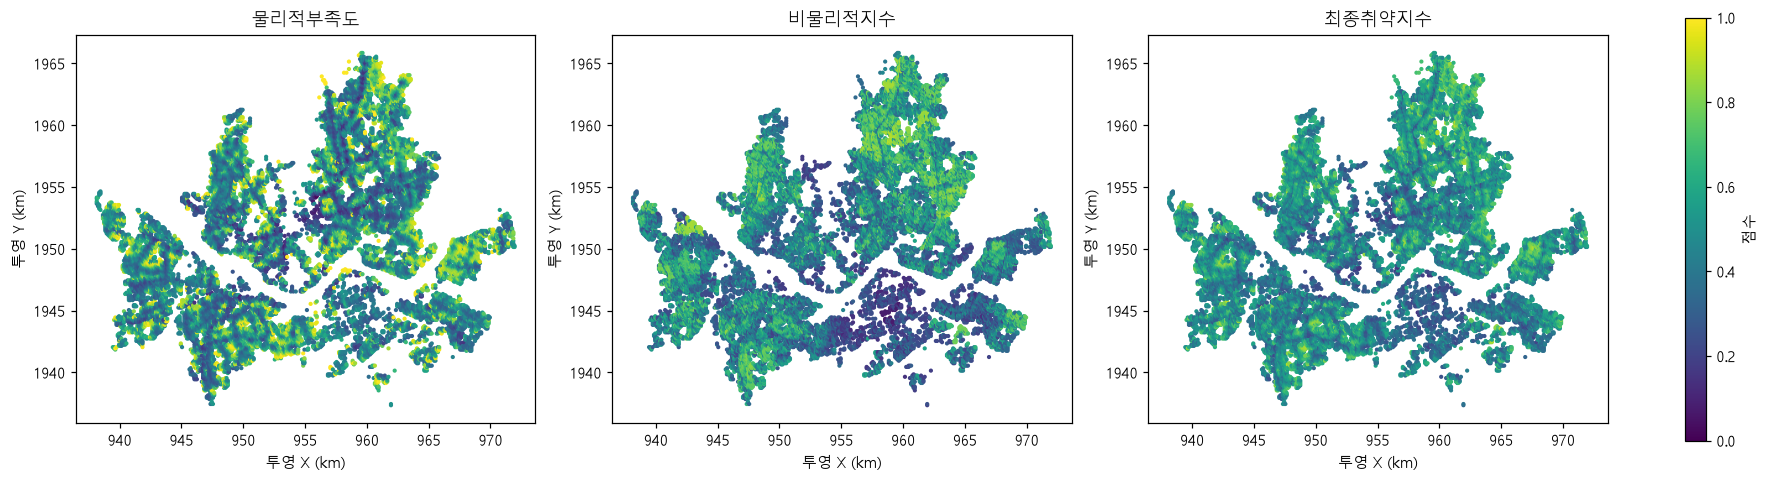

In [4]:
fig,axes=plt.subplots(1,3,figsize=(16,6),layout='constrained')
for ax,col in zip(axes,cols):
    sc=ax.scatter(df['중심점_x']/1000,df['중심점_y']/1000,c=df[col],s=3,cmap='viridis',vmin=0,vmax=1,rasterized=True)
    ax.set(aspect='equal',title=col,xlabel='투영 X (km)',ylabel='투영 Y (km)')
fig.colorbar(sc,ax=axes,label='점수',shrink=.65);plt.show()

## 3. 상위 10%와 대리 적용
서울 전체 대상 격자 점수의 90백분위 이상(동률 포함). 후보 선별 전 탐색적 상위집합이다.

전체 비교 상위 10%: 2,127격자 / 경계 0.6904 / 대리 적용 35격자


,GRID_CD,시군구,행정동,취약노인수,물리적부족도,비물리적지수,최종취약지수,경계대리적용
13176,다사588586,강북구,번2동,42,0.9915,0.8906,0.9411,False
19139,다사649548,중랑구,망우3동,20,1.0000,0.8316,0.9158,False
14319,다사598593,노원구,월계2동,30,1.0000,0.8253,0.9127,False
12941,다사586586,강북구,미아동,21,0.9898,0.8270,0.9084,False
14197,다사597585,강북구,번3동,24,0.9925,0.8240,0.9082,False
15852,다사613602,노원구,중계2·3동,33,0.9626,0.8526,0.9076,False
15849,다사613599,노원구,중계2·3동,46,0.9586,0.8564,0.9075,False
1569,다사423517,강서구,등촌3동,79,0.9684,0.8461,0.9072,False
12942,다사586587,강북구,미아동,18,0.9966,0.8141,0.9053,False
13055,다사587586,강북구,미아동,18,0.9902,0.8141,0.9021,False


상위격자수  취약노인수    평균최종점수
시군구 행정동                           
노원구 상계1동       57    757  0.763919
강동구 암사1동       49    754  0.797780
    천호2동       46    612  0.742841
노원구 중계2·3동     40   1307  0.780046
광진구 중곡4동       36    480  0.774904
노원구 공릉1동       35    603  0.733337
강동구 천호1동       34    533  0.752435
강서구 등촌3동       33   1606  0.772139
노원구 상계3·4동     30    659  0.753327
    상계5동       26    440  0.771555
강서구 화곡8동       24    295  0.787992
    화곡본동       23    312  0.782589
노원구 상계9동       22    151  0.752265
구로구 오류2동       22    217  0.739872
강북구 송중동        22    282  0.776735
    삼양동        22    371  0.756733
강서구 방화3동       22    481  0.788733
구로구 개봉2동       21    192  0.738906
동작구 상도3동       21    232  0.795575
도봉구 쌍문1동       20    269  0.781020

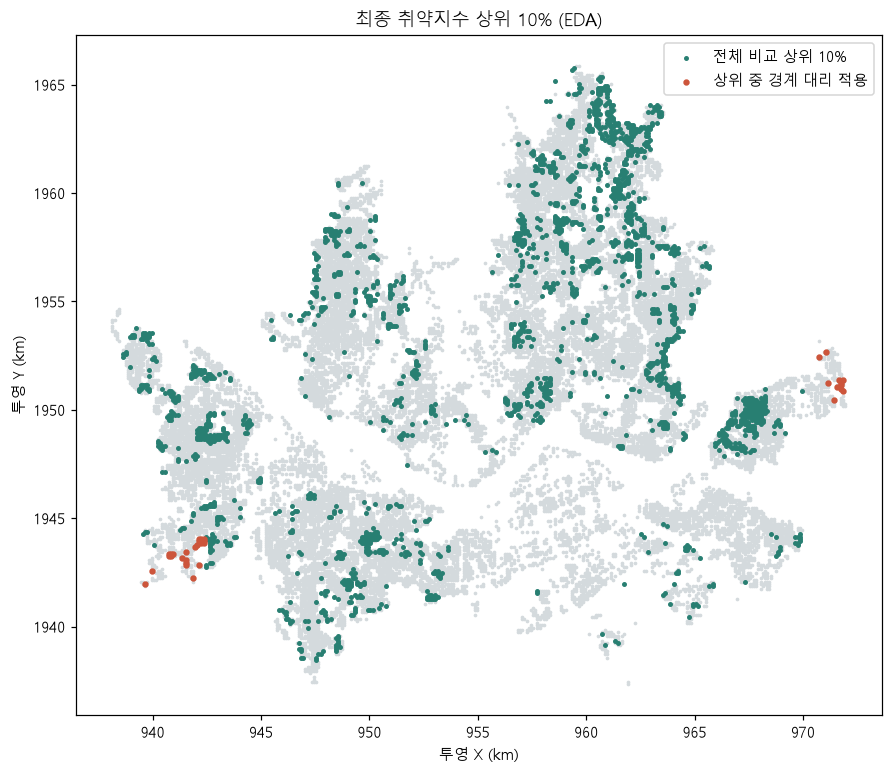

접근성 후보 기준 미정: 후보 내부 순위 시각화는 생략합니다.


In [5]:
cut=df['최종취약지수'].quantile(.9)
top=df.loc[df['최종취약지수'].ge(cut)].sort_values('최종취약지수',ascending=False)
print(f'전체 비교 상위 10%: {len(top):,}격자 / 경계 {cut:.4f} / 대리 적용 {top["경계대리적용"].sum()}격자')
display(top[['GRID_CD','시군구','행정동','취약노인수']+cols+['경계대리적용']].head(20).round(4))
display(top.groupby(['시군구','행정동']).agg(상위격자수=('GRID_CD','size'),취약노인수=('취약노인수','sum'),평균최종점수=('최종취약지수','mean')).sort_values('상위격자수',ascending=False).head(20))
fig,ax=plt.subplots(figsize=(8,7),layout='constrained')
ax.scatter(df['중심점_x']/1000,df['중심점_y']/1000,s=2,color='#d4dadd',rasterized=True)
ax.scatter(top['중심점_x']/1000,top['중심점_y']/1000,s=5,color='#287f72',label='전체 비교 상위 10%',rasterized=True)
proxy=top.loc[top['경계대리적용']]
ax.scatter(proxy['중심점_x']/1000,proxy['중심점_y']/1000,s=10,color='#cd553b',label='상위 중 경계 대리 적용')
ax.set(aspect='equal',title='최종 취약지수 상위 10% (EDA)',xlabel='투영 X (km)',ylabel='투영 Y (km)');ax.legend();plt.show()
if df['접근성후보'].isna().all():
    print('접근성 후보 기준 미정: 후보 내부 순위 시각화는 생략합니다.')
else:
    candidates=df.loc[df['접근성후보'].eq(True)].sort_values('최종취약순위_후보')
    print('실제 설정 기준의 후보 격자:',len(candidates))
    display(candidates[['GRID_CD','시군구','행정동']+cols+['최종취약순위_후보']].head(20))